# 01 - EDA

Goal: Analyze the motoretail dataset. Identify anomalies, missing values, and business patterns.

In [1]:
import os 
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path("..").resolve()
os.chdir(ROOT)

DATA_PATH = Path("data/raw/motoretail.csv")

df = pd.read_csv(DATA_PATH)

print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()

shape: (6875, 27)
columns: ['sale_date', 'sale_time', 'day_of_week', 'month', 'customer_type', 'customer_city', 'customer_state', 'customer_neighborhood', 'customer_address', 'customer_zipcode', 'product_name', 'product_category', 'quantity_sold', 'unit_cost_brl', 'unit_price_brl', 'discount_pct', 'total_revenue_brl', 'estimated_profit_brl', 'payment_method', 'sales_channel', 'weather_condition', 'delivery_app_peak', 'is_weekend', 'is_holiday_campaign', 'current_stock_snapshot', 'supplier_lead_time_days', 'returned']


,sale_date,sale_time,day_of_week,month,customer_type,customer_city,customer_state,customer_neighborhood,customer_address,customer_zipcode,...,estimated_profit_brl,payment_method,sales_channel,weather_condition,delivery_app_peak,is_weekend,is_holiday_campaign,current_stock_snapshot,supplier_lead_time_days,returned
0,2025-01-01,16:00,Quarta-feira,Janeiro,Novo,Caldas Novas,GO,Itanhangá II,"Rua São Paulo, 530",75680-195,...,153.75,Pix,Loja Física,Ensolarado,True,False,False,102,10,False
1,2025-01-01,14:30,Quarta-feira,Janeiro,Recorrente,Caldas Novas,GO,Jardim Belvedere,"Rua do Balneário, 3537",75685-204,...,104.78,Pix,Instagram,Ensolarado,False,False,False,23,9,False
2,2025-01-01,13:15,Quarta-feira,Janeiro,Recorrente,Caldas Novas,GO,Portal das Águas,"Av. Orcalino Santos, 760",75683-891,...,84.85,Pix,Loja Física,Ensolarado,True,False,False,54,9,False
3,2025-01-01,18:00,Quarta-feira,Janeiro,Novo,Caldas Novas,GO,Itanhangá II,"Rua do Balneário, 8761",75683-267,...,42.55,Pix,Instagram,Ensolarado,False,False,False,47,7,False
4,2025-01-01,11:30,Quarta-feira,Janeiro,Novo,Caldas Novas,GO,Nova Vila,"Rua São Paulo, 6492",75687-246,...,144.42,Pix,WhatsApp,Ensolarado,True,False,False,93,8,False


## Missing Values

In [2]:
missing_pct = df.isna().mean().mul(100).round(2).to_frame("pct_missing")
missing_pct

,pct_missing
sale_date,0.0
sale_time,0.0
day_of_week,0.0
month,0.0
customer_type,0.0
customer_city,0.0
customer_state,0.0
customer_neighborhood,0.0
customer_address,0.0
customer_zipcode,0.0


## Customer and Products Distribuition

Analysing the distribuition of the **key** inputs:

In [3]:
count_customer = df["customer_type"].value_counts()
customer_pct =(count_customer / count_customer.sum() * 100).round(2)
customer_dist = pd.DataFrame({"pct": customer_pct})

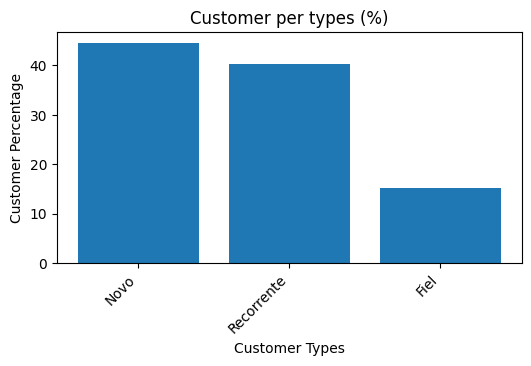

In [55]:
plt.figure(figsize=(6,3))
plt.bar(
    customer_dist.index.tolist(),
    customer_dist["pct"]
)

plt.title("Customer per types (%)")
plt.xlabel("Customer Types")
plt.ylabel("Customer Percentage")

plt.xticks(rotation=45, ha="right")

plt.show()

In [5]:
count_payment = df["payment_method"].value_counts()
payment_pct =(count_payment / count_payment.sum() * 100).round(2)
payment_dist = pd.DataFrame({"pct": payment_pct})

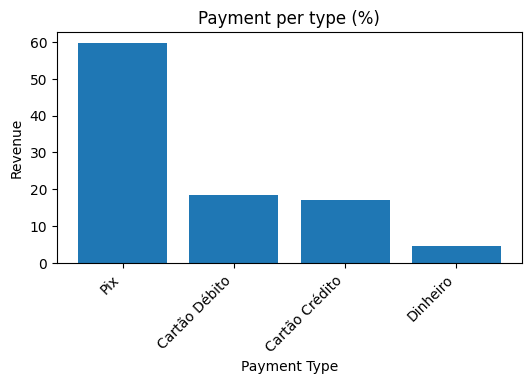

In [6]:
plt.figure(figsize=(6,3))
plt.bar(
    payment_dist.index.tolist(),
    payment_dist["pct"]
)

plt.title("Payment per type (%)")
plt.xlabel("Payment Type")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.show()

## Product Performance

In [7]:
count_product = df["product_category"].value_counts()
product_pct =(count_product / count_product.sum() * 100).round(2)
product_dist = pd.DataFrame({"pct": product_pct})

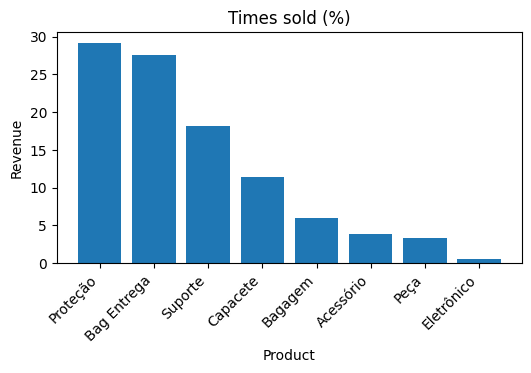

In [8]:
plt.figure(figsize=(6,3))
plt.bar(
    product_dist.index.tolist(),
    product_dist["pct"]
)

plt.title("Times sold (%)")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.show()

## Profit Performance

In [49]:
profit = (
    df
    .groupby("product_name", as_index=False)
    .agg({
        "estimated_profit_brl": "sum"
    })
    .sort_values("estimated_profit_brl")
)


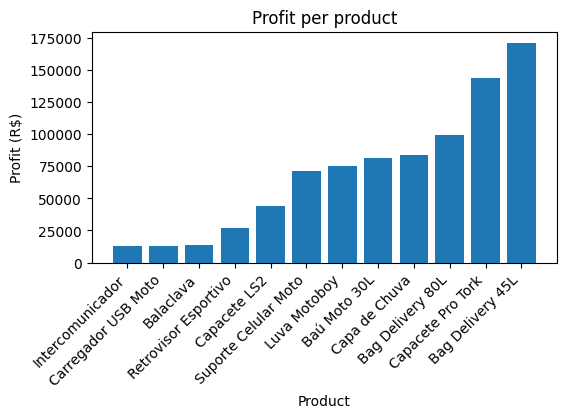

In [50]:
plt.figure(figsize=(6,3))
plt.bar(
    profit["product_name"],
    profit["estimated_profit_brl"]
)

plt.title("Profit per product")
plt.xlabel("Product")
plt.ylabel("Profit (R$)")

plt.xticks(rotation=45, ha="right")

plt.show()

## Revenue Performance

In [53]:
revenue = (
    df
    .groupby("product_name", as_index=False)
    .agg({
        "total_revenue_brl": "sum"
    })
    .sort_values("total_revenue_brl")
)

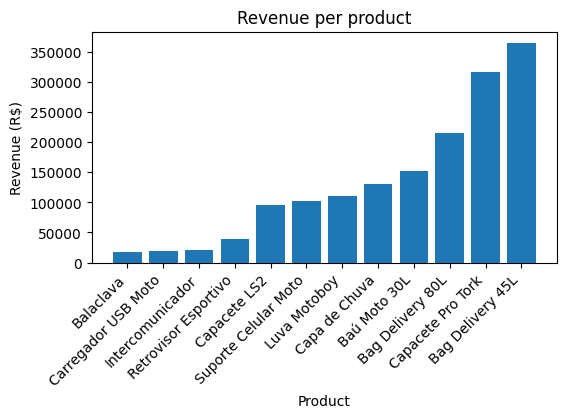

In [54]:
plt.figure(figsize=(6,3))
plt.bar(
    revenue["product_name"],
    revenue["total_revenue_brl"]
)

plt.title("Revenue per product")
plt.xlabel("Product")
plt.ylabel("Revenue (R$)")

plt.xticks(rotation=45, ha="right")

plt.show()

## Days Impact

In [11]:
count_day = df["day_of_week"].value_counts()
day_pct =(count_day / count_day.sum() * 100).round(2)
day_dist = pd.DataFrame({"pct": day_pct})

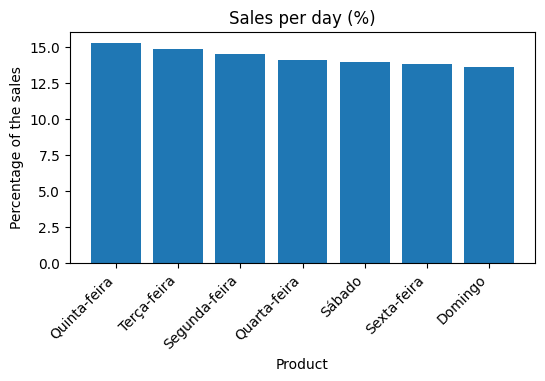

In [12]:
plt.figure(figsize=(6,3))
plt.bar(
    day_dist.index.tolist(),
    day_dist["pct"]
)

plt.title("Sales per day (%)")
plt.xlabel("Days")
plt.ylabel("Percentage of the sales")

plt.xticks(rotation=45, ha="right")

plt.show()

# Month Impact

In [13]:
count_month = df["month"].value_counts()
month_pct =(count_month / count_month.sum() * 100).round(2)
month_dist = pd.DataFrame({"pct": month_pct})

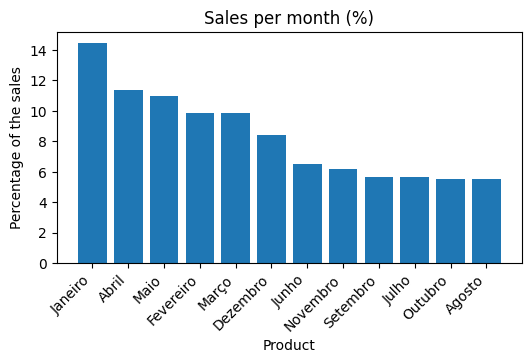

In [14]:
plt.figure(figsize=(6,3))
plt.bar(
    month_dist.index.tolist(),
    month_dist["pct"]
)

plt.title("Sales per month (%)")
plt.xlabel("Moth")
plt.ylabel("Percentage of the sales")

plt.xticks(rotation=45, ha="right")

plt.show()

## Weather Impact

In [34]:
weather_impact = (
    df
    .groupby("weather_condition", as_index=False)
    .agg(
        total_estimated_profit_brl=("estimated_profit_brl", "sum")
    )
    .sort_values(by="total_estimated_profit_brl", ascending=False)
)

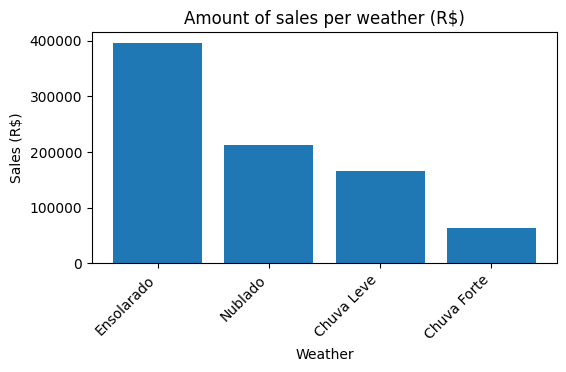

In [35]:
plt.figure(figsize=(6,3))
plt.bar(
    weather_impact["weather_condition"],
    weather_impact["total_estimated_profit_brl"]
)

plt.title("Amount of sales per weather (R$)")
plt.xlabel("Weather")
plt.ylabel("Sales (R$)")

plt.xticks(rotation=45, ha="right")

plt.show()

## Campaign Impact

In [36]:
campaign_impact = (
    df
    .groupby("is_holiday_campaign", as_index=False)
    .agg({
        "estimated_profit_brl": "sum"
    })
    .sort_values("estimated_profit_brl")
)


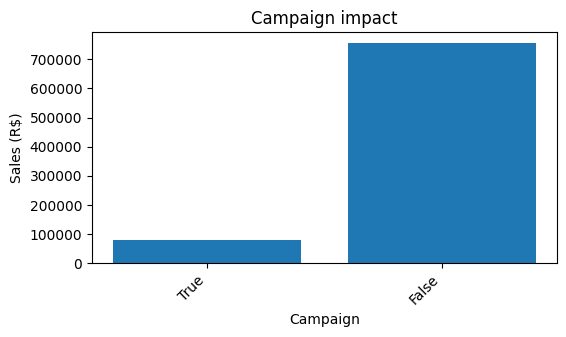

In [37]:
plt.figure(figsize=(6,3))
plt.bar(
    campaign_impact["is_holiday_campaign"].astype(str),
    campaign_impact["estimated_profit_brl"]
)

plt.title("Campaign impact")
plt.xlabel("Campaign")
plt.ylabel("Sales (R$)")

plt.xticks(rotation=45, ha="right")

plt.show()

## Channel Pattern

In [38]:
channel_sales = (
    df
    .groupby("sales_channel", as_index=False)
    .agg({
        "estimated_profit_brl": "sum"
    })
    .sort_values("estimated_profit_brl")
)


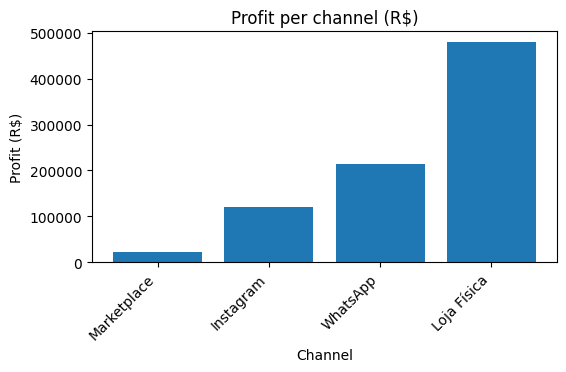

In [56]:
plt.figure(figsize=(6,3))
plt.bar(
    channel_sales["sales_channel"],
    channel_sales["estimated_profit_brl"]
)

plt.title("Profit per channel (R$)")
plt.xlabel("Channel")
plt.ylabel("Profit (R$)")

plt.xticks(rotation=45, ha="right")

plt.show()

## Stock Pattern

In [ ]:
product_stock = (
    df
    .groupby("product_name", as_index=False)
    .agg({
        "current_stock_snapshot": "min"
    })
    .sort_values("product_name", ascending=True)
)

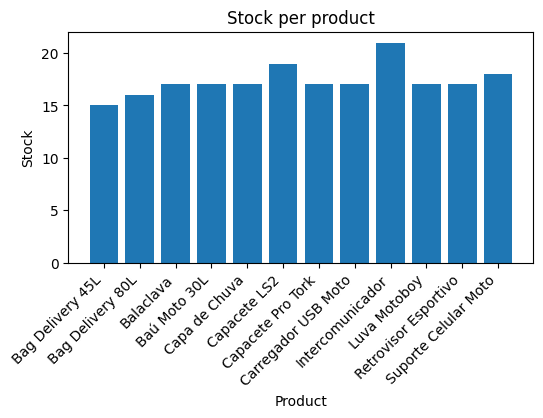

In [47]:
plt.figure(figsize=(6,3))
plt.bar(
    product_stock["product_name"],
    product_stock["current_stock_snapshot"]
)

plt.title("Stock per product")
plt.xlabel("Product")
plt.ylabel("Stock")

plt.xticks(rotation=45, ha="right")

plt.show()

## Business Findings

### Main Findings

* Sales are concentrated in a few key categories, mainly **Proteção**, **Bag Entrega** and **Capacete**.
* The strongest products in revenue and estimated profit are higher-ticket items, especially **Capacete LS2**, **Intercomunicador**, **Capacete Pro Tork**, **Bag Delivery 80L** and **Baú Moto 30L**.
* Sales tend to be stronger on **Friday, Saturday and Sunday**, showing higher demand near the weekend.
* **January** has the highest sales percentage, which may indicate seasonal demand.
* Holiday campaigns are not very frequent, but they show potential to increase average profit per sale.
* **Loja Física** has the highest estimated profit, although sales channels are relatively balanced.

### Potential Risks

* The business depends heavily on a few high-performing products and categories.
* Stockouts in profitable products may directly impact revenue and estimated profit.
* Campaigns may be underused, especially if they continue showing better average profit per sale.
* Weekend demand requires better stock planning to avoid missed sales.
* Weather analysis should be interpreted carefully, because total profit can be affected by how often each weather condition appears in the dataset.

### Recommendations

* Prioritize stock planning for the most profitable products.
* Create low-stock alerts for products with high estimated profit.
* Use campaigns more strategically and compare their impact on revenue, sales volume and average profit.
* Prepare inventory before weekends and seasonal peaks such as January.
* Continue the project with demand forecasting by product to support smarter inventory decisions.
